# Renewable Power Output and Weather Conditions

### Predicting solar irradiance (GHI) from weather observations


Methodology:

ETL
- Import data
- Clean data (check for missing values, duplicates, what are the data types, how many unique values, etc.)

Exploratory Data Analysis
- Correlation Matrix (find high correlations)
- Analysis of Energy Delta to Time
- Analysis of Energy Delta to GHI
- Analysis of Energy Delta to SunlightTime

- Polynomial expansion
- Derive columns

Data Preparation
- K-Fold Cross Validation
- Drop Columns


In [ ]:
# Import libraries
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Read csv
df = pd.read_csv('./Renewable.csv')
df.drop(columns=['Time', 'sunlightTime', 'dayLength'], inplace=True)
df.head()

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,SunlightTime/daylength,weather_type,hour,month
0,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0.0,4,0,1
1,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0.0,4,0,1
2,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0.0,4,0,1
3,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0.0,4,0,1
4,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0.0,4,1,1


In [ ]:
# Finding the data types, adjusting if necessary
# df.Time = pd.to_datetime(df['Time'])
df.dtypes

,0
Energy delta[Wh],int64
GHI,float64
temp,float64
pressure,int64
humidity,int64
wind_speed,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
isSun,int64


In [ ]:
#df.columns = ["Time","Energy Delta[Wh]","GHI","temp","pressure","humidity","wind_speed","rain_1h","snow_1h","clouds_all","isSun","sunlightTime","dayLength","SunlightTime/daylength","weather_type","hour","month"]
#cols = ["Energy Delta[Wh]","GHI","temp","pressure","humidity","wind_speed","rain_1h","snow_1h","sunlightTime","dayLength","SunlightTime/daylength","weather_type","hour","month"]

# Checking for null values in each column
count = df.isnull().sum()
print(count)

Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64


In [ ]:
# Checking for duplicate values
df.duplicated().sum()

69240

<Figure size 1500x1000 with 0 Axes>

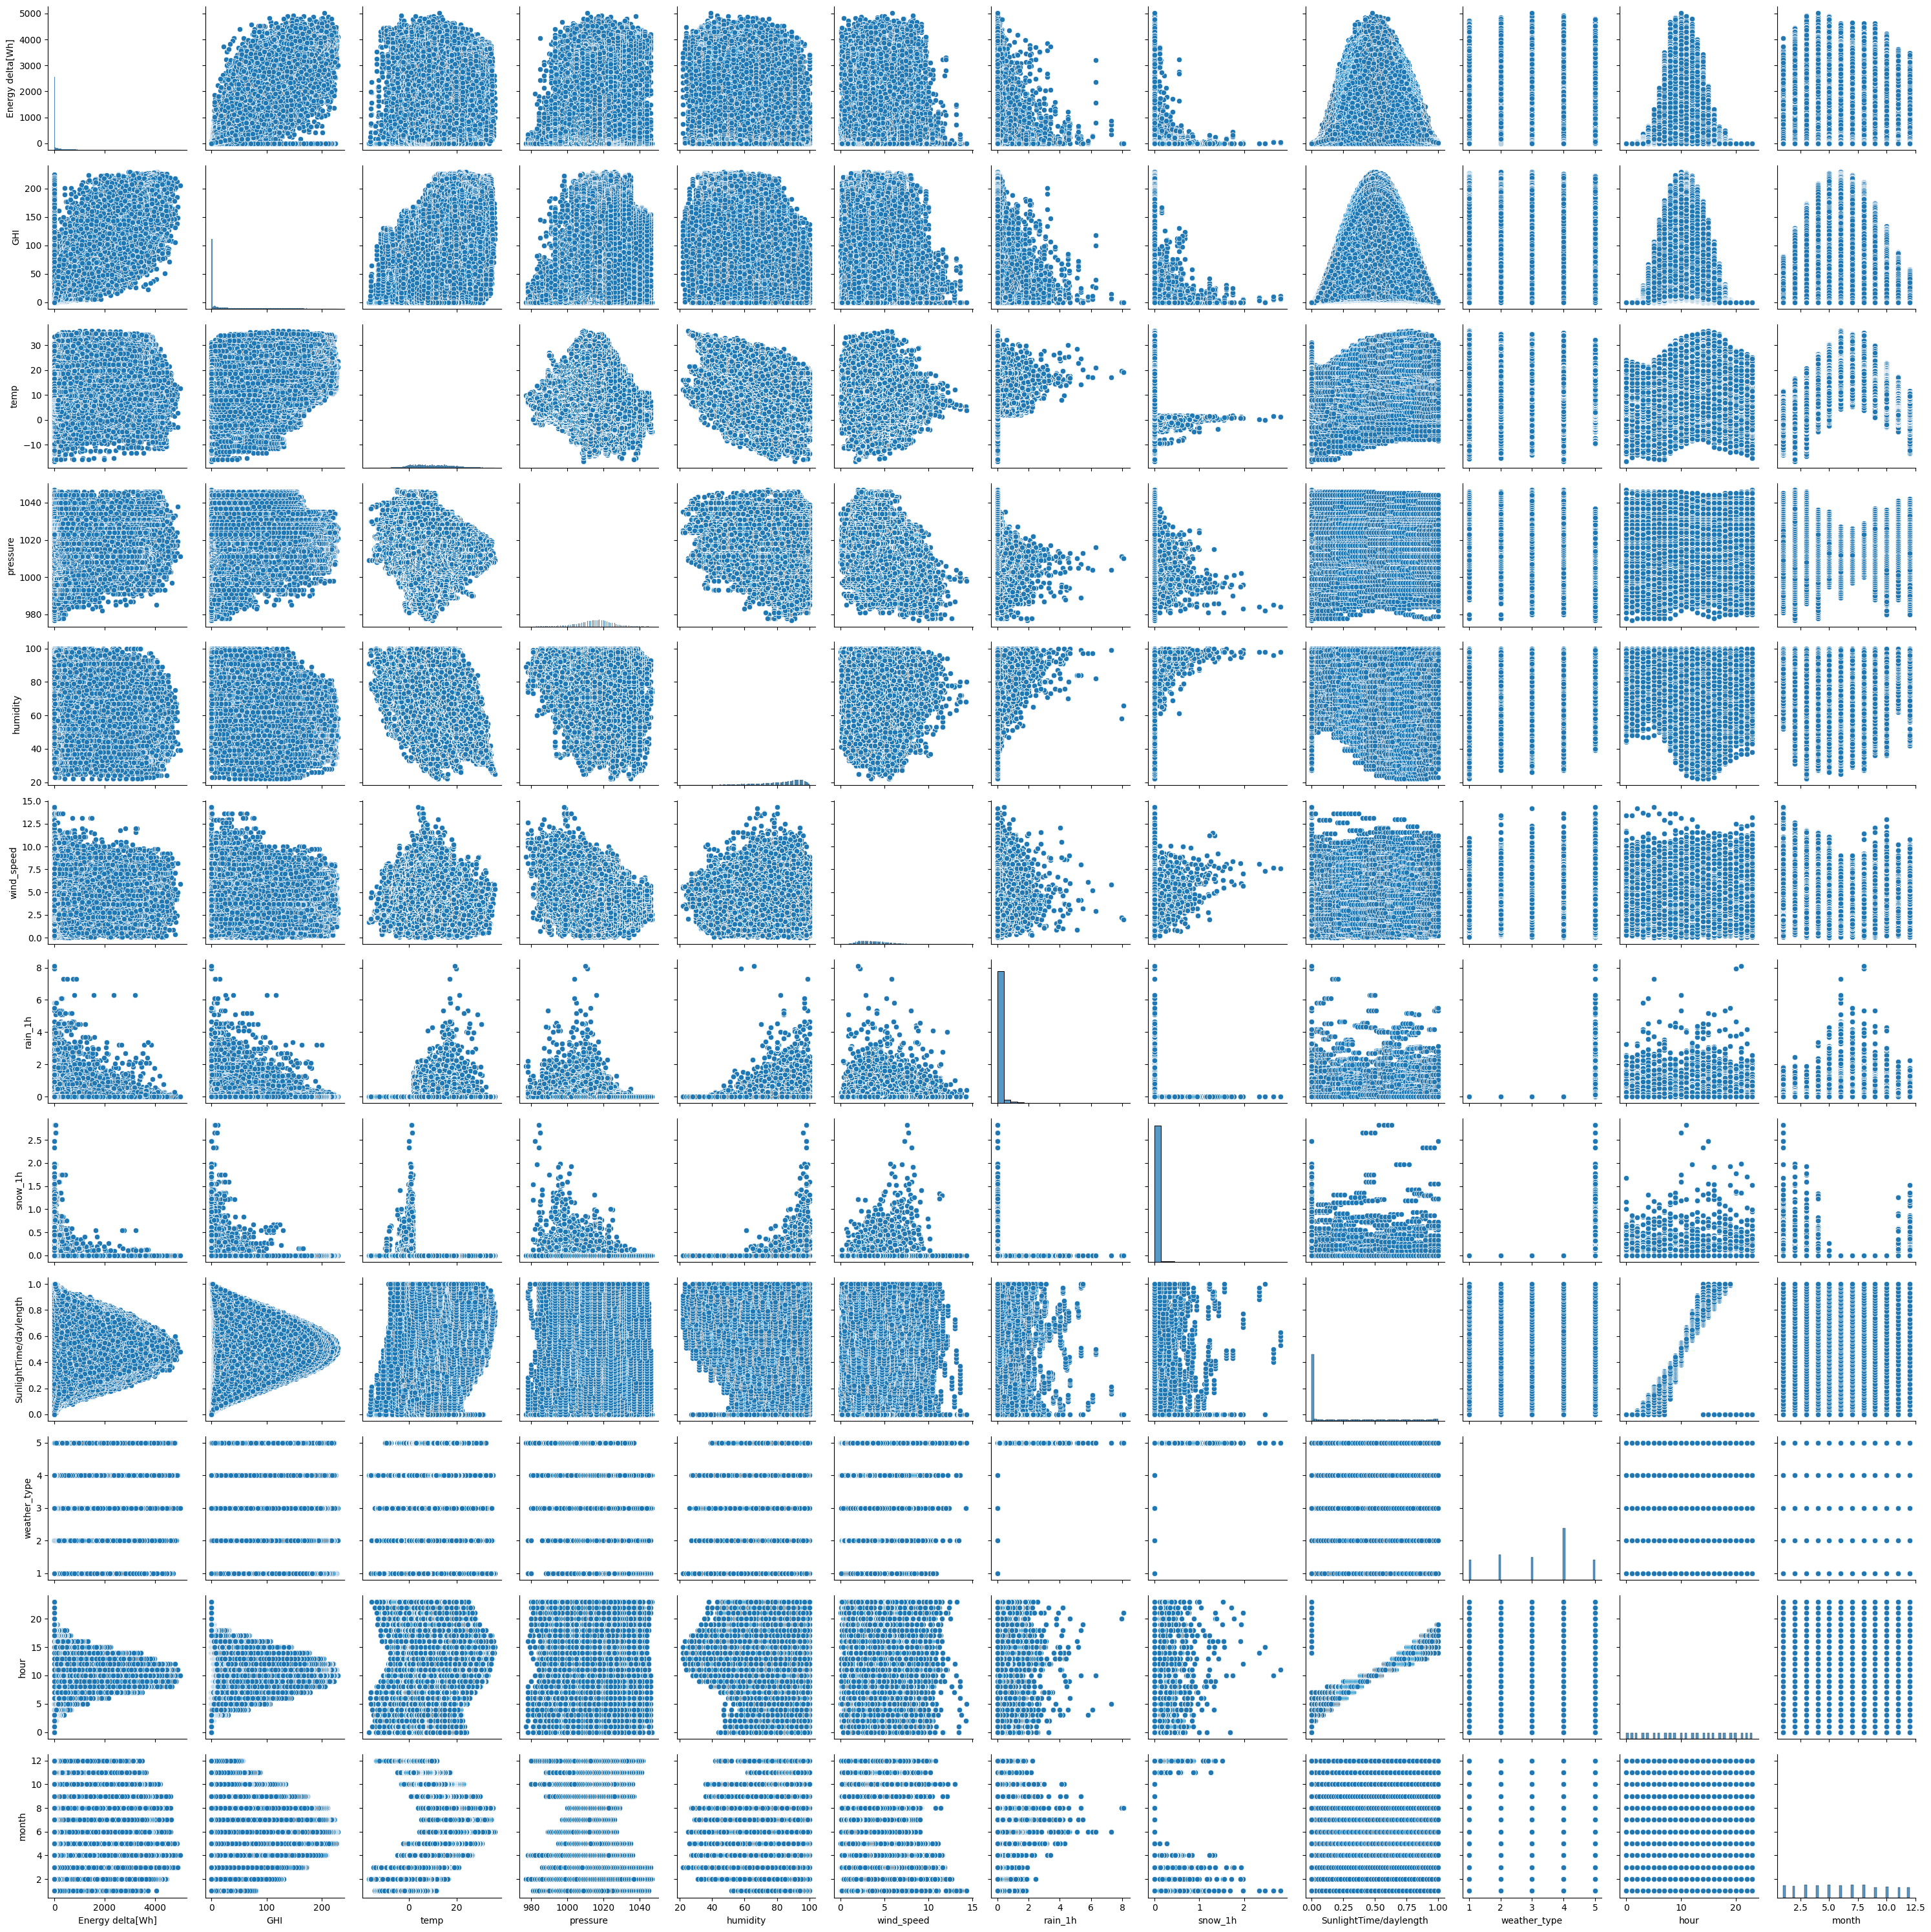

In [ ]:
numerical_cols = ["Energy delta[Wh]","GHI","temp","pressure","humidity","wind_speed","rain_1h","snow_1h","SunlightTime/daylength","weather_type","hour","month"]

plt.figure(figsize=(15, 10))
sns.pairplot(df[numerical_cols], height=2.5)
plt.tight_layout()
plt.show()

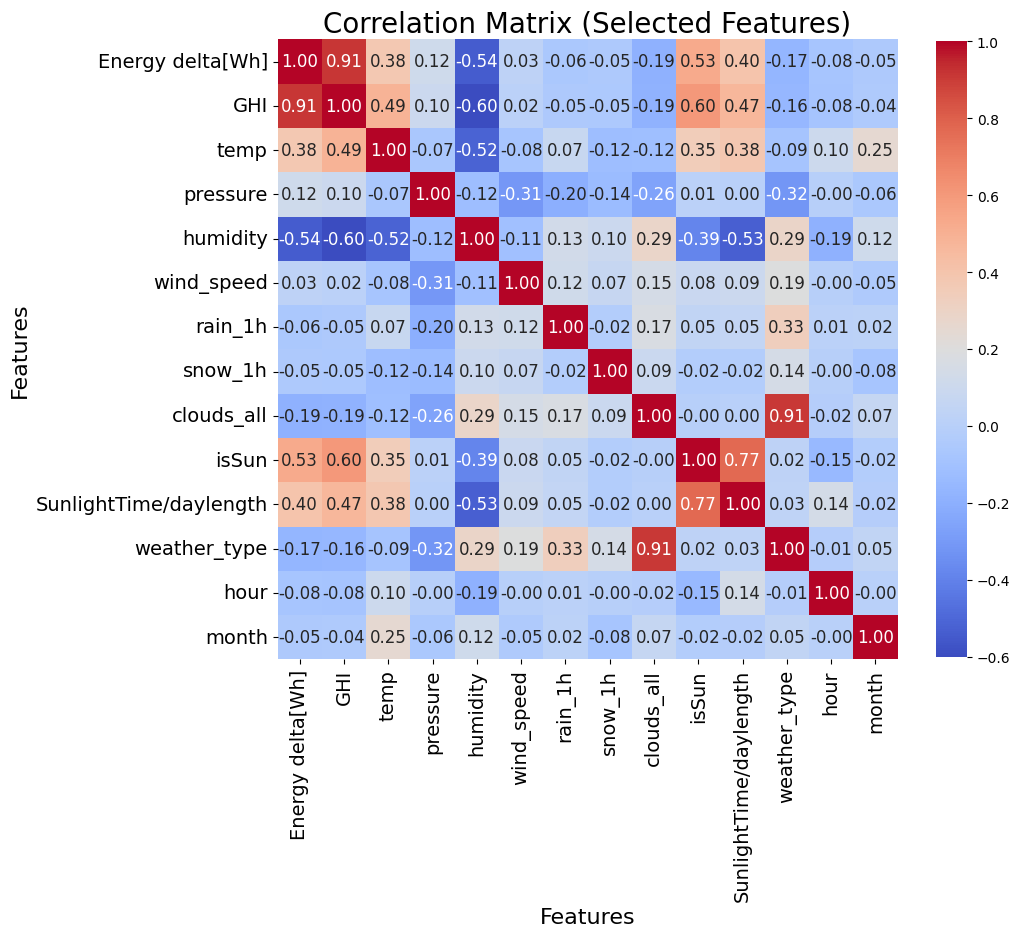

In [ ]:
# Making a correlation matrix of all the features
correlation_matrix = df.corr()

plt.figure(figsize=(10, 10))
hm = sns.heatmap(correlation_matrix,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 12},  # Increase font size for the numbers
                 cbar_kws={'shrink': 0.8},
                 yticklabels=correlation_matrix.columns,
                 xticklabels=correlation_matrix.columns,
                 cmap='coolwarm')  # Set the color map to 'coolwarm' (blue to red)
plt.title("Correlation Matrix (Selected Features)", fontsize=20)  # Bigger title
plt.xlabel("Features", fontsize=16)  # Bigger x-axis label
plt.ylabel("Features", fontsize=16)  # Bigger y-axis label
plt.xticks(fontsize=14)  # Increase font size for x-axis tick labels
plt.yticks(fontsize=14)  # Increase font size for y-axis tick labels
plt.show()

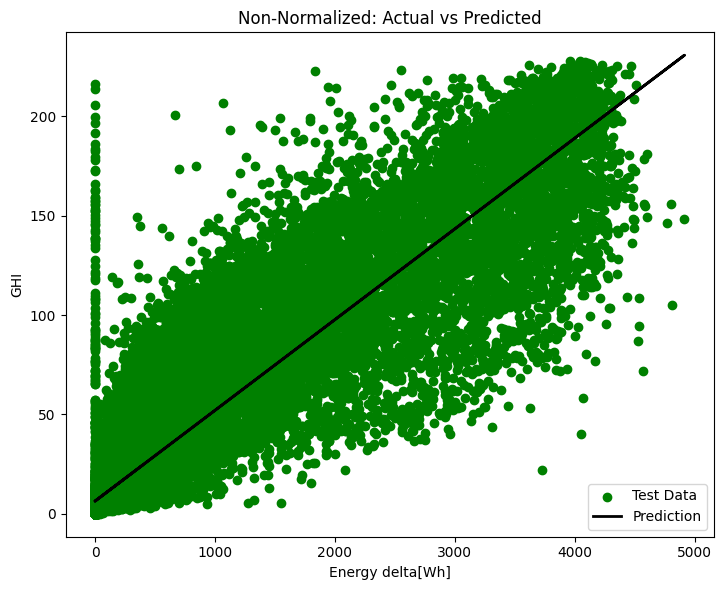

RMSE: 21.04 R2: 0.84
Training RMSE: 21.11
Training R²: 0.84


In [ ]:
# Using most correlated pair set values to be trained
X = df[['Energy delta[Wh]']].values
Y = df[['GHI']].values

# Split data into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Simple Linear Model on non-normalized data
non_norm_model = LinearRegression()
non_norm_model.fit(X_train, Y_train)

Y_test_non_norm_predict = non_norm_model.predict(X_test)
Y_train_non_norm_predict = non_norm_model.predict(X_train)

#getting RMSE and R2 for non normalized models
rmse_test_non_norm = np.sqrt(mean_squared_error(Y_test, Y_test_non_norm_predict))
r2_test_non_norm = r2_score(Y_test, Y_test_non_norm_predict)

rmse_train_non_norm = np.sqrt(mean_squared_error(Y_train, Y_train_non_norm_predict))
r2_train_non_norm = r2_score(Y_train, Y_train_non_norm_predict)

#Non-norm data
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_test, Y_test, color='green', label='Test Data')
plt.plot(X_test, Y_test_non_norm_predict, color='black', lw=2, label='Prediction')
plt.xlabel('Energy delta[Wh]')
plt.ylabel('GHI')
plt.title('Non-Normalized: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()

print(f"RMSE: {rmse_test_non_norm:.2f} R2: {r2_test_non_norm:.2f}")
print(f"Training RMSE: {rmse_train_non_norm:.2f}")
print(f"Training R²: {r2_train_non_norm:.2f}")

[0]	validation_0-rmse:44.97708
[1]	validation_0-rmse:38.84062
[2]	validation_0-rmse:33.98172
[3]	validation_0-rmse:30.19384
[4]	validation_0-rmse:28.55461
[5]	validation_0-rmse:25.88189
[6]	validation_0-rmse:23.79938
[7]	validation_0-rmse:22.16961
[8]	validation_0-rmse:21.57529
[9]	validation_0-rmse:21.13640
[10]	validation_0-rmse:20.81234
[11]	validation_0-rmse:20.57571
[12]	validation_0-rmse:20.35505
[13]	validation_0-rmse:20.18876
[14]	validation_0-rmse:20.05142
[15]	validation_0-rmse:19.21888
[16]	validation_0-rmse:18.61218
[17]	validation_0-rmse:18.13079
[18]	validation_0-rmse:17.74505
[19]	validation_0-rmse:17.45708
[20]	validation_0-rmse:17.23100
[21]	validation_0-rmse:17.06575
[22]	validation_0-rmse:16.92834
[23]	validation_0-rmse:16.88474
[24]	validation_0-rmse:16.85336
[25]	validation_0-rmse:16.72849
[26]	validation_0-rmse:16.69737
[27]	validation_0-rmse:16.67110
[28]	validation_0-rmse:16.57042
[29]	validation_0-rmse:16.49430
[30]	validation_0-rmse:16.42155
[31]	validation_0-

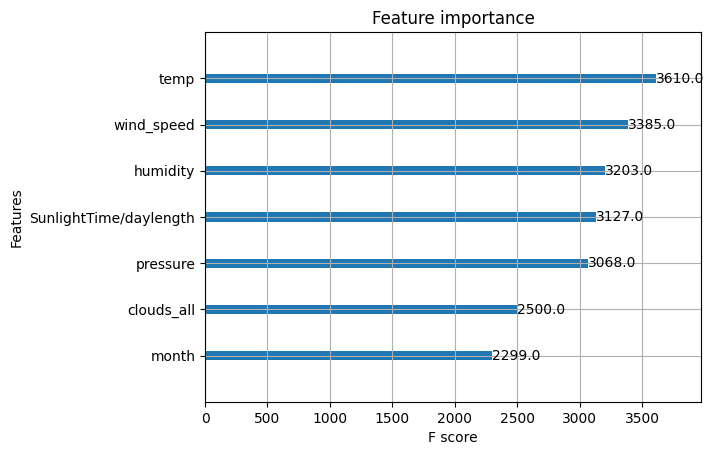

In [ ]:
#3

# Using most correlated pair set values to be trained
X = df[['temp', 'pressure', 'wind_speed', 'humidity', 'clouds_all', 'SunlightTime/daylength', 'month']]
Y = df[['GHI']].values

# Split data into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=200,     # Number of trees
    learning_rate=0.2,    # Step size shrinkage
    max_depth=7,         # Maximum depth of a tree
    subsample=0.8,        # Row sampling
    colsample_bytree=0.8, # Feature sampling
    early_stopping_rounds = 10, # If model isn't improving stop
    reg_lambda = 1000, # Penalty
    random_state=42
)

# Train the model
model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)])

# Make predictions
Y_pred = model.predict(X_test)
Y_train_pred = model.predict(X_train)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
r2_train = r2_score(Y_train, Y_train_pred)

print(f"Testing: RMSE: {rmse} r2: {r2}")
print(f"Training: RMSE: {rmse_train} r2: {r2_train}")

# Plot feature importance
xgb.plot_importance(model, importance_type="weight")
plt.show()

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3936/3936 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 536.3281 - mae: 11.0075 - val_loss: 174.8807 - val_mae: 6.8317
Epoch 2/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 204.2548 - mae: 7.3453 - val_loss: 158.4304 - val_mae: 6.3146
Epoch 3/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 190.7166 - mae: 7.0245 - val_loss: 179.4346 - val_mae: 6.7661
Epoch 4/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 183.1783 - mae: 6.8647 - val_loss: 152.3380 - val_mae: 6.1401
Epoch 5/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 173.0963 - mae: 6.7043 - val_loss: 154.0926 - val_mae: 6.2229
Epoch 6/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 168.1571 - mae: 6.5717 - val_loss: 158.4175 - val_mae: 6.3809
Epoch 7/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 162.9126 - mae: 6.5063 - val_loss: 169.8356 - val_mae: 6.6217
Epoch 8/10
3936/3936 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 156.8370 - mae: 6.3880 - val_loss: 226.6045 - val_mae: 7.8773
Epoch 9/10


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Test Loss: 208.30703735351562
Test MAE: 7.598146438598633
R²: 0.9243
RMSE: 14.4329
Training R²: 0.9239
Training RMSE: 14.3689


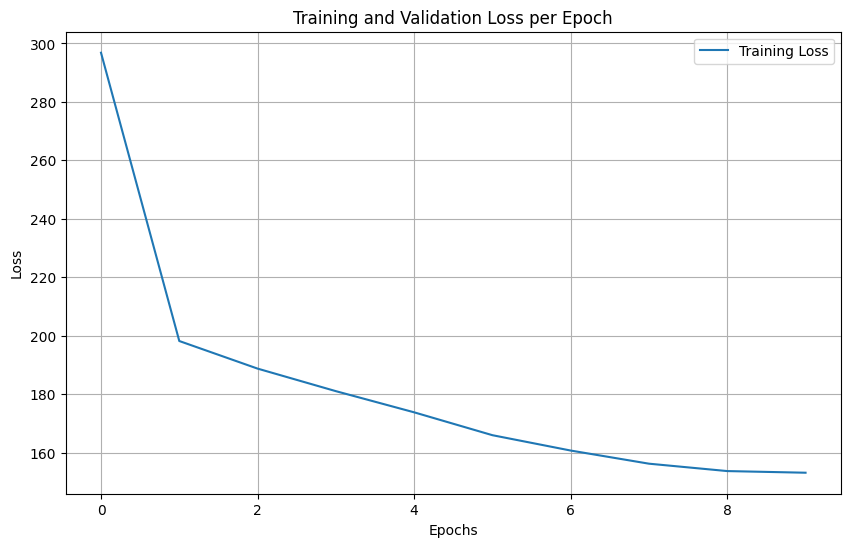

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data preparation
X = df.drop(columns=["GHI"])
Y = df["GHI"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model definition
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
y_train_pred = model.predict(X_train_scaled)

# Calculate R² and RMSE
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)

# Print results
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Training R²: {r2_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")

# Plot training and validation loss per epoch
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid()
plt.show()
